# 📋 Descripción  

Este cuaderno registra la obtención de datos para el estudio de la eficiencia del estudio de los alumnos, partiremos de la submuestra de colegios generada en el análisis global incorporando los datos necesarior para este apartado.

Seleccion de variables:

**Estudiantes (`STU_QQQ_SAS`)**

| Código de variable | Descripción y rol en el proyecto |
| :--- | :--- |
| `ST296Q01JA` | Tiempo diario dedicado a los deberes de Matemáticas. |
| `ST296Q04JA` | Tiempo total acumulado diario en deberes de todas las asignaturas. |
| `STUDYHMW` | Índice derivado de frecuencia semanal de estudio antes/después de clase. |
| `ST307Q07JA` | Perseverancia: *"Dejo de hacer los deberes si son demasiado largos"*. |
| `ST309Q05JA` | Autorregulación: *"Reviso cuidadosamente los deberes antes de entregarlos"*. |
| `ESCS` | Índice socioeconómico individual (control obligatorio). |
| `PERSEVAGR` / `MATHPERS` | Índices estandarizados de perseverancia general y esfuerzo en matemáticas. |
| `W_FSTUWT` / `SENWT` / `STRATUM`  (Ajustados)| Pesos de muestreo (final, senado y estrato) para el diseño muestral. |

 **Escuelas (`SCH_QQQ_SAS`)**

| Código de variable | Descripción y rol en el proyecto |
| :--- | :--- |
| `SC212Q01JA` | Disponibilidad de salas donde el alumnado puede hacer los deberes. |
| `SC212Q02JA` | Disponibilidad de personal del centro que ayuda con los deberes. |
| `SC212Q03JA` | Disponibilidad de tutoría de deberes entre iguales (*peer-to-peer*). |

**Tiempos (`STU_TIM_SAS`)**

| Código de variable | Descripción y rol en el proyecto |
| :--- | :--- |
| `ST296_TT`, `ST307_TT`, `ST309_TT` | Tiempo de respuesta asociado a los bloques de preguntas sobre deberes, perseverancia y autorregulación. |

**Cognitivo (`STU_COG_SAS`)**

| Código de variable | Descripción y rol en el proyecto |
| :--- | :--- |
| `PV1MATH` a `PV10MATH` | Los 10 Valores Plausibles de matemáticas (**variables objetivo / target**). |

# Preparación de los datos

Se carga la submuestra de escuelas creada en el cuaderno global y se prepara la lectura por bloques del fichero de estudiantes. La tabla inicial contendrá las variables de deberes y los identificadores necesarios para filtrar y relacionar los datos.

In [38]:
import gc
import os
import pickle
import sys
from pathlib import Path
import missingno as msno

#Se indica la ruta del workspace principal (Dos niveles atras)
sys.path.append(os.path.abspath('../../'))

#Se indica la comprobacion de cambio de librerias externas
%load_ext autoreload
%autoreload 2



The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [39]:

import numpy as np
import pandas as pd
import pyreadstat
from src.utils_pisa import *

In [111]:
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns

In [40]:

ruta_datos_raw = Path('../../data/raw')
ruta_datos_intermedios = Path('../../data/intermediate')
ruta_datos_estudiante = ruta_datos_raw / 'CY08MSP_STU_QQQ.SAS7BDAT'
ruta_datos_escuelas = ruta_datos_raw / 'CY08MSP_SCH_QQQ.SAS7BDAT'
ruta_datos_tiempos = ruta_datos_raw / 'CY08MSP_STU_TIM.SAS7BDAT'
ruta_submuestra = ruta_datos_intermedios / 'escuelas_seleccionadas.pkl'
ruta_pesos_ajustados= ruta_datos_intermedios / 'pesos_senado_alumno_mapeados.pkl'
ruta_media_matematicas = ruta_datos_intermedios / 'medias_math_alumno.parquet'


In [41]:
establecer_semilla()

✅ Semillas del proyecto establecidas con éxito (seed=42).


In [42]:
pd.set_option('display.float_format', lambda x: '%.2f' % x)

## Lectura de estudiantes por bloques

Se conservan las variables de interés del cuestionario de estudiantes y las claves que permiten filtrar las escuelas seleccionadas.

In [43]:
#Cargamos el set de datos donde se indica el ID de las escuelas seleccionadas y los factoresd e inflacion
escuelas_seleccionadas_set, factores_dict = cargar_pickle(ruta_submuestra)

#Carrgamos los pesos de alumnos y senado ajustados
df_pesos_ajustados = cargar_pickle(ruta_pesos_ajustados)

#Cargamos las media de matamáticas del alumno 

df_notas_mates = pd.read_parquet(ruta_media_matematicas)



 Objetos cargados correctamente desde: ..\..\data\intermediate\escuelas_seleccionadas.pkl
 Objetos cargados correctamente desde: ..\..\data\intermediate\pesos_senado_alumno_mapeados.pkl


In [44]:
list(escuelas_seleccionadas_set)[:5]

[('MNG', 'MNG16', np.float64(49600017.0)),
 ('JPN', 'JPN02', np.float64(39200033.0)),
 ('LVA', 'LVA03', np.float64(42800027.0)),
 ('ARE', 'ARE21', np.float64(78400711.0)),
 ('MEX', 'MEX07', np.float64(48400129.0))]

In [45]:
df_pesos_ajustados.head()

,CNT,CNTSCHID,CNTSTUID,W_FSTUWT_adj,SENWT_adj
0,ALB,800282.00,800001.00,15.79,2.84
1,ALB,800242.00,800003.00,39.19,7.04
2,ALB,800172.00,800007.00,21.30,3.83
3,ALB,800040.00,800015.00,22.07,3.96
4,ALB,800123.00,800024.00,20.62,3.70


In [46]:
df_notas_mates.head()

,CNT,CNTSCHID,CNTSTUID,media_math_pisa
0,ALB,800282.00,800001.00,223.04
1,ALB,800115.00,800002.00,308.49
2,ALB,800242.00,800003.00,313.74
3,ALB,800245.00,800005.00,298.73
4,ALB,800285.00,800006.00,475.75


In [47]:
#Establecemos las columnas de interes para cada uno de los dataframes que vamos a procesar

#STU_QQQ.SAS7BDAT
columnas_estudiantes = [
    'CNT', 'STRATUM', 'CNTSCHID', 'CNTSTUID',
    'ST296Q01JA', 'ST296Q04JA', 'STUDYHMW',
    'ST307Q07JA', 'ST309Q05JA', 'ESCS',
    'PERSEVAGR', 'MATHPERS'
]

#SCH_QQQ.SAS7BDAT
columnas_escuelas = [
    'CNT', 'STRATUM', 'CNTSCHID',
    'SC212Q01JA', 'SC212Q02JA', 'SC212Q03JA'
]

#STU_TIM.SAS7BDAT
columnas_tiempos = [
    'CNT', 'CNTSTUID', 'ST296_TT', 'ST307_TT', 'ST309_TT'
]


In [48]:
#Reader para el archivo de estudiantes en chunks (el mas grande de todos) 
chunk_size = 10_000
reader = pyreadstat.read_file_in_chunks(
    pyreadstat.read_sas7bdat,
    str(ruta_datos_estudiante),
    chunksize=chunk_size,
    usecols=columnas_estudiantes
)

In [49]:

chunks_filtrados = []

for chunk, _ in reader:
    #Creamos la clave temporal en forma de tupla en cada chunk
    chunk['clave_colegio_temp'] = list(zip(
        chunk['CNT'],
        chunk['STRATUM'],
        chunk['CNTSCHID']
    ))

    #De cada chunk nos quedamos solo con las escuelas presentes en el set
    chunk_filtrado = chunk.loc[
        chunk['clave_colegio_temp'].isin(escuelas_seleccionadas_set),
        columnas_estudiantes
    ].copy()

    if not chunk_filtrado.empty:
        chunks_filtrados.append(chunk_filtrado) #Añadimos el chunk filtrado resultante a la lista de chunks

if not chunks_filtrados:
    raise ValueError('La lectura no encontró estudiantes de las escuelas seleccionadas.')

df_estudiantes_submuestra = pd.concat(chunks_filtrados, ignore_index=True)
del chunks_filtrados
gc.collect()

df_estudiantes_submuestra.shape

(146500, 12)

In [50]:
df_estudiantes_submuestra.info(memory_usage='deep')

<class 'pandas.DataFrame'>
RangeIndex: 146500 entries, 0 to 146499
Data columns (total 12 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   CNT         146500 non-null  str    
 1   STRATUM     146500 non-null  str    
 2   CNTSCHID    146500 non-null  float64
 3   CNTSTUID    146500 non-null  float64
 4   ST296Q01JA  129738 non-null  float64
 5   ST296Q04JA  129071 non-null  float64
 6   STUDYHMW    137226 non-null  float64
 7   ST307Q07JA  61702 non-null   float64
 8   ST309Q05JA  66206 non-null   float64
 9   ESCS        140451 non-null  float64
 10  PERSEVAGR   83349 non-null   float64
 11  MATHPERS    119631 non-null  float64
dtypes: float64(10), str(2)
memory usage: 14.6 MB


## Lectura de escuelas & Tiempos

Se cargan las variables de apoyo escolar disponibles en el fichero de escuelas y los tiempos de respuesta de los bloques relacionados con deberes. En ambos casos se filtran los registros de la submuestra.

### Escuelas

In [51]:
# El fichero de escuelas es reducido; se carga solo con las columnas necesarias.
df_escuelas = pyreadstat.read_sas7bdat(
    str(ruta_datos_escuelas),
    usecols=columnas_escuelas
)[0] #Nos quedamos solo con los datos, no los metadatos


In [52]:
#Realizamos el mismo procedimento pero sin leer en chunks 

df_escuelas['clave_colegio_temp'] = list(zip( #Generamos una tupla que contiene la clave a buscar
    df_escuelas['CNT'],
    df_escuelas['STRATUM'],
    df_escuelas['CNTSCHID']
))

df_escuelas_submuestra = df_escuelas.loc[ #Buscamos en el set la identificacion de los paises de la submuestra las correspondencias
    df_escuelas['clave_colegio_temp'].isin(escuelas_seleccionadas_set),
    columnas_escuelas
].copy()
del df_escuelas

if df_escuelas_submuestra.empty:
    raise ValueError('La lectura no encontró escuelas de la submuestra en el fichero de escuelas.')

df_escuelas_submuestra.info(memory_usage='deep')

<class 'pandas.DataFrame'>
Index: 5113 entries, 3 to 21624
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   CNT         5113 non-null   str    
 1   STRATUM     5113 non-null   str    
 2   CNTSCHID    5113 non-null   float64
 3   SC212Q01JA  4622 non-null   float64
 4   SC212Q02JA  4627 non-null   float64
 5   SC212Q03JA  4629 non-null   float64
dtypes: float64(4), str(2)
memory usage: 320.8 KB


### Tiempos

Realizamos la lectura por bloques tambien

In [53]:
reader_tiempos = pyreadstat.read_file_in_chunks(
    pyreadstat.read_sas7bdat,
    str(ruta_datos_tiempos),
    chunksize=chunk_size,
    usecols=columnas_tiempos
)

In [54]:
chunks_tiempos_filtrados = []

#Generamos las claves
claves_estudiantes = set(zip(
    df_estudiantes_submuestra['CNT'],
    df_estudiantes_submuestra['CNTSTUID']
))

for chunk_tiempos, _ in reader_tiempos:
    claves_chunk = list(zip(chunk_tiempos['CNT'], chunk_tiempos['CNTSTUID']))
    chunk_tiempos_filtrado = chunk_tiempos.loc[
        pd.Series(claves_chunk, index=chunk_tiempos.index).isin(claves_estudiantes),
        columnas_tiempos
    ].copy()

    if not chunk_tiempos_filtrado.empty:
        chunks_tiempos_filtrados.append(chunk_tiempos_filtrado)

if not chunks_tiempos_filtrados:
    raise ValueError('La lectura no encontró registros de tiempo para los estudiantes de la submuestra.')



In [55]:
df_tiempos_submuestra = pd.concat(chunks_tiempos_filtrados, ignore_index=True)
df_tiempos_submuestra.info()

<class 'pandas.DataFrame'>
RangeIndex: 146500 entries, 0 to 146499
Data columns (total 5 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   CNT       146500 non-null  str    
 1   CNTSTUID  146500 non-null  float64
 2   ST296_TT  135516 non-null  float64
 3   ST307_TT  131728 non-null  float64
 4   ST309_TT  130351 non-null  float64
dtypes: float64(4), str(1)
memory usage: 6.0 MB


In [56]:
#Limpiamos la memorias
del chunks_tiempos_filtrados, claves_chunk
gc.collect()

0

In [57]:

#Generamos un nuevo ataframe con las columnas necesarias
df_analisis_deberes = (
    df_estudiantes_submuestra
    .merge(
        df_escuelas_submuestra,
        on=['CNT', 'STRATUM', 'CNTSCHID'],
        how='left',
        validate='many_to_one'    # Escuelas (Muchos estudiantes -> Una escuela)
    )
    .merge(
        df_tiempos_submuestra,
        on=['CNT', 'CNTSTUID'],
        how='left',
        validate='one_to_one' # Tiempos (Un estudiante -> Un registro de tiempos)
    )
    .merge(
        df_pesos_ajustados,
        on=['CNT', 'CNTSCHID', 'CNTSTUID'],
        how='left',
        validate='one_to_one'     # Pesos Ponderados (Un estudiante -> Un conjunto de pesos)
    )
    .merge(
        df_notas_mates,
        on=['CNT', 'CNTSCHID', 'CNTSTUID'],
        how='left',
        validate = 'one_to_one'
)


)



In [58]:
df_analisis_deberes.info()

<class 'pandas.DataFrame'>
RangeIndex: 146500 entries, 0 to 146499
Data columns (total 21 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   CNT              146500 non-null  str    
 1   STRATUM          146500 non-null  str    
 2   CNTSCHID         146500 non-null  float64
 3   CNTSTUID         146500 non-null  float64
 4   ST296Q01JA       129738 non-null  float64
 5   ST296Q04JA       129071 non-null  float64
 6   STUDYHMW         137226 non-null  float64
 7   ST307Q07JA       61702 non-null   float64
 8   ST309Q05JA       66206 non-null   float64
 9   ESCS             140451 non-null  float64
 10  PERSEVAGR        83349 non-null   float64
 11  MATHPERS         119631 non-null  float64
 12  SC212Q01JA       134931 non-null  float64
 13  SC212Q02JA       135121 non-null  float64
 14  SC212Q03JA       135274 non-null  float64
 15  ST296_TT         135516 non-null  float64
 16  ST307_TT         131728 non-null  float64
 17  ST

In [59]:
df_analisis_deberes.head(2)

,CNT,STRATUM,CNTSCHID,CNTSTUID,ST296Q01JA,ST296Q04JA,STUDYHMW,ST307Q07JA,ST309Q05JA,ESCS,...,MATHPERS,SC212Q01JA,SC212Q02JA,SC212Q03JA,ST296_TT,ST307_TT,ST309_TT,W_FSTUWT_adj,SENWT_adj,media_math_pisa
0,ALB,ALB03,800282.00,800001.00,3.00,6.00,10.00,NaN,5.00,1.11,...,-0.01,1.00,1.00,1.00,23779.00,177.00,28351.00,15.79,2.84,223.04
1,ALB,ALB01,800242.00,800003.00,2.00,2.00,0.00,NaN,NaN,-0.19,...,NaN,2.00,2.00,1.00,16409.00,573.00,554.00,39.19,7.04,313.74


In [60]:
#Guardamos eldataframe sin procesaro en formato parquet
ruta_df_analisis_deberes = ruta_datos_intermedios/'pisa_df_deberes_no_procesado.parquet'



In [61]:
df_analisis_deberes.to_parquet(ruta_df_analisis_deberes,engine='pyarrow', index=False)

In [90]:
df_analisis_deberes = pd.read_parquet(ruta_df_analisis_deberes)

# EDA

In [91]:
#Trasnformamos los ID que aparecen como floar en STR
#TODO ver que hacer para que no se conviertan en float
columnas_ids = ['CNTSCHID', 'CNTSTUID']
for col in columnas_ids:

    df_analisis_deberes[col] = df_analisis_deberes[col].astype('Int64').astype(str)

In [139]:
# Convertimos las categorías de duración a horas y damos nombres descriptivos a las columnas.
# Según el diccionario PISA: 1 (<30m), 2 (30m-1h), 3 (1-2h), 4 (2-3h), 5 (3-4h), 6 (>4h).
mapeo_horas = {
    1: 0.25,
    2: 0.75,
    3: 1.50,
    4: 2.50,
    5: 3.50,
    6: 4.50
}

columnas_horas = ['ST296Q01JA', 'ST296Q04JA']
for columna in columnas_horas:
    df_analisis_deberes[columna] = df_analisis_deberes[columna].map(mapeo_horas)

renombrado_columnas = {
    'ESCS': 'Estatus_Socioeconomico',              # Control principal de contexto
    'PERSEVAGR': 'Perseverancia_General',           # Actitud y resiliencia
    'MATHPERS': 'Perseverancia_Matematicas',        # Actitud específica hacia la materia
    'ST307_TT': 'Tiempo_Respuesta_Fatiga',          # Control de esfuerzo (Rapid Responders)
    'SC212Q01JA': 'Salas_Estudio_Disponibles',      # Recurso del centro escolar
    'STUDYHMW': 'Indice_Frecuencia_Estudio',        # Hábito de estudio autónomo
    'ST296Q04JA': 'Horas_Deberes_Totales',          # Carga horaria total de deberes
    'ST309_TT': 'Tiempo_Respuesta_Revision',        # Control de esfuerzo en revisión
    'MATHPERS': 'Perseverancia_Matematicas',        # Persistencia en matemáticas
    'ST296_TT': 'Tiempo_Respuesta_Deberes',         # Control de esfuerzo en deberes
    'ST296Q01JA': 'Horas_Deberes_Matematicas',      # Carga horaria específica de mates
    'ST309Q05JA': 'Revision_Deberes',               # Estrategia de autocontrol
    'ST307Q07JA': 'Abandono_Por_Fatiga',            # Indicador de fatiga conductual
    'SC212Q02JA': 'Personal_Apoyo_Disponible',      # Recursos humanos del colegio
    'SC212Q03JA': 'Tutorias_Disponibles'            # Apoyo académico extraescolar
}

# df_analisis_deberes = df_analisis_deberes.rename(columns=renombrado_columnas)
# df_analisis_deberes.head()

In [93]:
#Calulamos el porcentaje de nulos del dataframe
pct_nulos_total = (df_analisis_deberes.isnull().sum() / len(df_analisis_deberes)) * 100


In [94]:
print(pct_nulos_total.sort_values(ascending=False))

ST307Q07JA        57.88
ST309Q05JA        54.81
PERSEVAGR         43.11
MATHPERS          18.34
ST296Q04JA        11.90
ST296Q01JA        11.44
ST309_TT          11.02
ST307_TT          10.08
SC212Q01JA         7.90
SC212Q02JA         7.77
SC212Q03JA         7.66
ST296_TT           7.50
STUDYHMW           6.33
ESCS               4.13
CNTSCHID           0.00
STRATUM            0.00
CNT                0.00
CNTSTUID           0.00
W_FSTUWT_adj       0.00
SENWT_adj          0.00
media_math_pisa    0.00
dtype: float64


<Axes: >

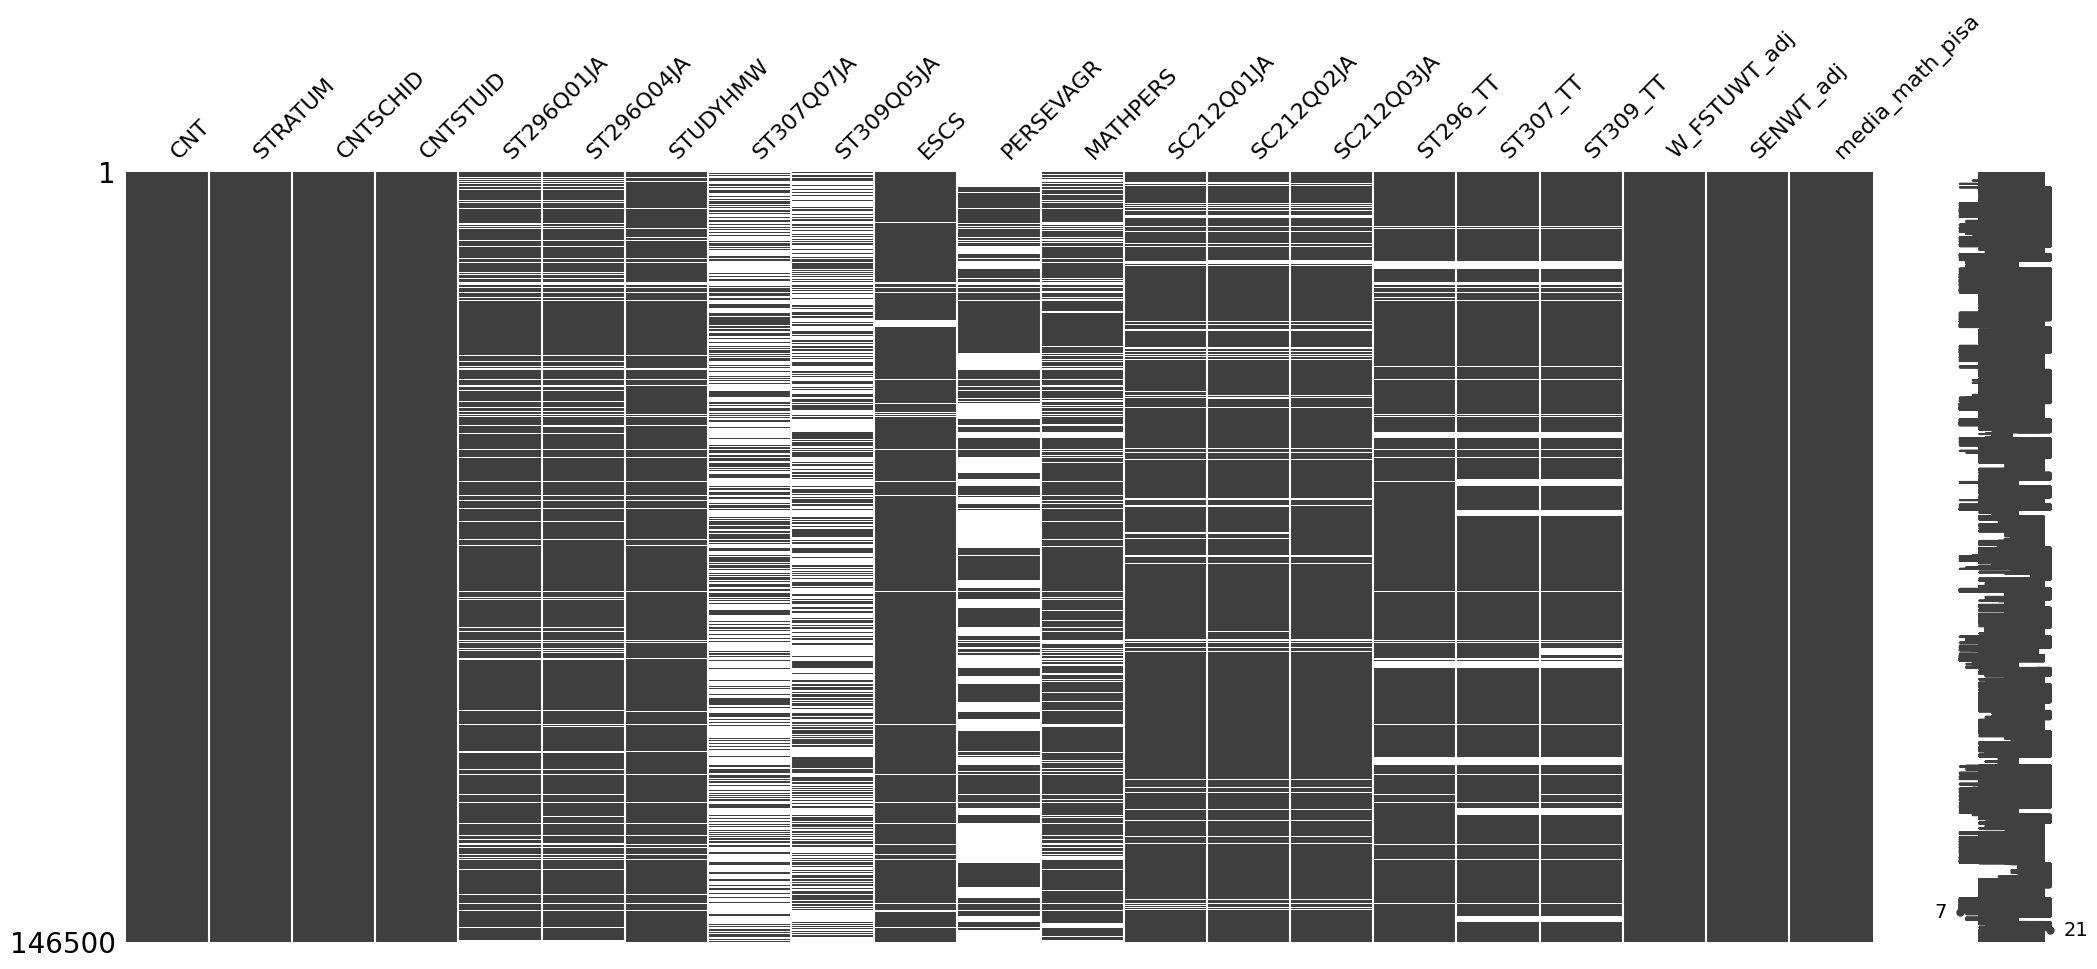

In [95]:
msno.matrix(df_analisis_deberes)


<div style="
  background: linear-gradient(135deg, rgba(128, 128, 128, 0.25) 0%, rgba(64, 64, 64, 0.15) 100%);
  backdrop-filter: blur(4px);
  -webkit-backdrop-filter: blur(4px);
  border-left: 5px solid rgba(128, 128, 128, 0.6);
  padding: 16px;
  border-radius: 8px;
  color: inherit;
  margin: 20px 0;
">
  <strong style="display: block; margin-bottom: 6px; font-size: 1.1em;">
    💡 Nulos en indicadores
  </strong>
   Los nulos indican que los datos estén corruptos, sino que responden al diseño de cuadernillos rotatorios de la OCDE (no a todos los alumnos se les hacen todas las preguntas psicológicas por falta de tiempo).
</div>


Filtrado de los **Rapid Responders** : Alumnos que contestan sin leer el enunciado y contestan de forma aleatoria y rápida. Filtramos antes de pasar los datos al modelo para mejorar la eficiencia del modelo

In [96]:
print(df_analisis_deberes['ST296_TT'].describe())

count    135516.00
mean      22777.73
std       18848.11
min           7.00
25%       14234.00
50%       20832.00
75%       28730.00
max     3085893.00
Name: ST296_TT, dtype: float64


El tiempo esta en milisegundos, pero podemos ver que la media de resouesta en aproximadamente en 22,7 segundos. Existe un minimo de 7ms que puede ser un click aleatorio o un error el el sistema. Definiremos entonces el humbral 
controlar el esfuerzo demostrado al hacer el examen y no confundir una nota baja por culpa de los deberes con una nota baja por simplemente no leer las preguntas.

Definiremos un umbral para filtrar las respuesta, basandonos en la media, un tiempo de respuesta adecuado pueden ser 3 segundos


In [97]:
umbral_minimo_ms = 4000.0
rapid_responders = df_analisis_deberes[df_analisis_deberes['ST296_TT'] < umbral_minimo_ms]
print(f"Alumnos eliminados por contestar en menos de 4 segundos: {len(rapid_responders)}")

Alumnos eliminados por contestar en menos de 4 segundos: 8385


In [98]:
df_analisis_deberes_noRP = df_analisis_deberes[df_analisis_deberes['ST296_TT'] >= umbral_minimo_ms].copy()
print(f"Filas restantes para el modelo: {df_analisis_deberes_noRP.shape[0]}")

Filas restantes para el modelo: 127131


In [99]:
df_analisis_deberes_noRP.head()

,CNT,STRATUM,CNTSCHID,CNTSTUID,ST296Q01JA,ST296Q04JA,STUDYHMW,ST307Q07JA,ST309Q05JA,ESCS,...,MATHPERS,SC212Q01JA,SC212Q02JA,SC212Q03JA,ST296_TT,ST307_TT,ST309_TT,W_FSTUWT_adj,SENWT_adj,media_math_pisa
0,ALB,ALB03,800282,800001,1.50,4.50,10.00,NaN,5.00,1.11,...,-0.01,1.00,1.00,1.00,23779.00,177.00,28351.00,15.79,2.84,223.04
1,ALB,ALB01,800242,800003,0.75,0.75,0.00,NaN,NaN,-0.19,...,NaN,2.00,2.00,1.00,16409.00,573.00,554.00,39.19,7.04,313.74
2,ALB,ALB04,800172,800007,1.50,2.50,10.00,5.00,5.00,1.09,...,2.34,1.00,1.00,2.00,18874.00,13632.00,19552.00,21.30,3.83,521.28
4,ALB,ALB06,800123,800024,1.50,4.50,10.00,NaN,NaN,-0.89,...,2.72,1.00,1.00,1.00,18427.00,30772.00,41648.00,20.62,3.70,425.45
6,ALB,ALB03,800282,800030,0.75,0.75,10.00,NaN,4.00,-1.04,...,-0.42,1.00,1.00,1.00,22020.00,4278.00,38225.00,15.79,2.84,357.57


## Selecion de caracteristicas ( _Feature Importance_)

Nos quedaremos solo con las variables de interes para el modelo, eliminando la información geográfica y de estratos para evitar sesgos del modelo. 

In [ ]:
columnas_excluidas = [
    'CNT',            # País
    'STRATUM',        # Estrato
    'CNTSCHID',       # ID del colegio
    'CNTSTUID',       # ID del alumno
    'W_FSTUWT_adj',   # Peso original (estamos usando SENWT_adj para el modelo)
    'SENWT_adj',      # Peso de senado (no debe aprender de él, solo usarlo como ponderación)
    'media_math_pisa',# Nota de matemáticas
    'ESCS'            #Estatus socio económico (No tiene tanto que ver con deberes)
]

In [143]:
#Preparamos los datos para el modelo
features= df_analisis_deberes_noRP.drop(columns=columnas_excluidas).reset_index(drop=True)
target = df_analisis_deberes_noRP['media_math_pisa'].reset_index(drop=True)
pesos = df_analisis_deberes_noRP['SENWT_adj'].reset_index(drop=True)

In [144]:

modelo_deberes = xgb.XGBRegressor(
    n_estimators=100, max_depth=5, random_state=42, tree_method='hist'
)

modelo_deberes.fit(features, target, sample_weight=pesos)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [145]:
# Extraemos las variables mas importantes
tabla_importancia = pd.DataFrame({
    'Variable': features.columns,
    'Importancia': modelo_deberes.feature_importances_,
}).sort_values(by='Importancia', ascending=False).reset_index(drop=True)

tabla_importancia['Importancia']=tabla_importancia['Importancia']*100

In [146]:
tabla_importancia

,Variable,Importancia
0,PERSEVAGR,19.48
1,ST307_TT,15.93
2,SC212Q01JA,12.21
3,ST296Q04JA,8.29
4,MATHPERS,8.10
5,ST309_TT,7.75
6,STUDYHMW,7.00
7,ST296_TT,4.98
8,ST296Q01JA,4.78
9,ST309Q05JA,4.69


In [147]:
tabla_final = tabla_importancia.copy()

tabla_final.rename(columns={'Variable': 'Codigo_PISA'}, inplace=True)

tabla_final['Explicacion'] = tabla_final['Codigo_PISA'].map(renombrado_columnas)

tabla_final = tabla_final[['Codigo_PISA', 'Explicacion', 'Importancia']]



In [148]:
# Mostramos el resultado ordenado y limpio
tabla_final

,Codigo_PISA,Explicacion,Importancia
0,PERSEVAGR,Perseverancia_General,19.48
1,ST307_TT,Tiempo_Respuesta_Fatiga,15.93
2,SC212Q01JA,Salas_Estudio_Disponibles,12.21
3,ST296Q04JA,Horas_Deberes_Totales,8.29
4,MATHPERS,Perseverancia_Matematicas,8.10
5,ST309_TT,Tiempo_Respuesta_Revision,7.75
6,STUDYHMW,Indice_Frecuencia_Estudio,7.00
7,ST296_TT,Tiempo_Respuesta_Deberes,4.98
8,ST296Q01JA,Horas_Deberes_Matematicas,4.78
9,ST309Q05JA,Revision_Deberes,4.69
